# 19 · Cost, compute budgets & scheduling on a cluster

At scale the budget is money. We run the loop, read the `seconds` column, apply a
GPU-hour cost model, and find the point of diminishing returns — the information
that tells you when to stop paying.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import matplotlib; matplotlib.use("Agg")
import numpy as np, matplotlib.pyplot as plt
from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA, "| NOTE: these chapters scale to bdd-small/full; here we")
print("demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.")

dataset: ../data/bdd-tiny.lance | NOTE: these chapters scale to bdd-small/full; here we
demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.


In [2]:
from harness.loop import run_loop
run_loop(iters=8, dataset_path=str(DATA), results_path="results.tsv", verbose=False)
import pandas as pd
df = pd.read_csv("results.tsv", sep="\t")
GPU_USD_PER_HR = 2.50
df["cum_seconds"] = df["seconds"].cumsum()
df["cum_usd"] = df["cum_seconds"] / 3600 * GPU_USD_PER_HR
df[["iter", "score", "best_so_far", "seconds", "cum_usd"]].round(3)

,iter,score,best_so_far,seconds,cum_usd
0,0,0.884,0.884,6.07,0.004
1,1,0.972,0.972,5.79,0.008
2,2,0.974,0.974,5.86,0.012
3,3,1.018,1.018,11.24,0.020
4,4,0.951,1.018,22.76,0.036
5,5,1.019,1.019,11.85,0.044
6,6,0.974,1.019,11.53,0.052
7,7,0.928,1.019,11.85,0.060
8,8,0.974,1.019,11.08,0.068


score gain 0.135 for $0.0681 (modeled)
policy: stop when marginal score / $ falls below a program.md threshold


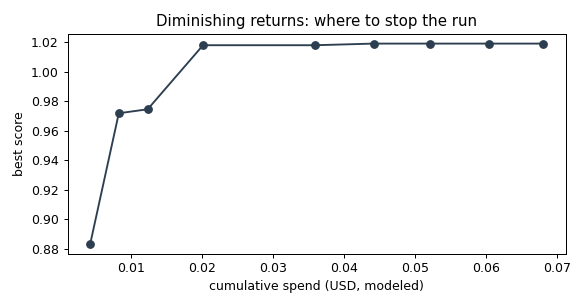

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(df["cum_usd"], df["best_so_far"], "-o", color="#2c3e50")
ax.set_xlabel("cumulative spend (USD, modeled)"); ax.set_ylabel("best score")
ax.set_title("Diminishing returns: where to stop the run")
fig.tight_layout(); fig.savefig("fig_19_cost.png", dpi=90); plt.close(fig)
gain = df["best_so_far"].iloc[-1] - df["best_so_far"].iloc[0]
print(f"score gain {gain:.3f} for ${df['cum_usd'].iloc[-1]:.4f} (modeled)")
print("policy: stop when marginal score / $ falls below a program.md threshold")
from IPython.display import Image; Image("fig_19_cost.png")

A run budget belongs in `program.md` so it's part of the immutable direction.
Ray's scheduler enforces it as infra: spot instances for fault-tolerant trials
(you checkpoint, Ch. 10), resource-aware placement, and early-stopping doomed
trials (ASHA) as cost control.